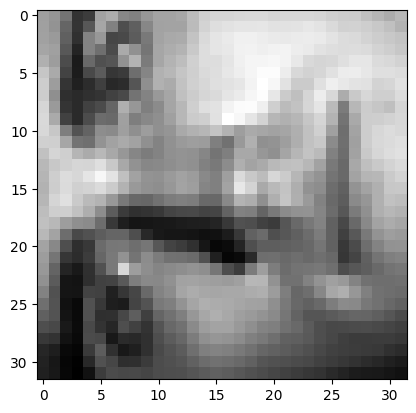

In [24]:
import numpy as np
from scipy.io import loadmat
results=loadmat('yalefaces.mat')
X=results['X']

# print an image of the matrix
import matplotlib.pyplot as plt
plt.imshow(X[:,5].reshape(32,32).T, cmap='gray')
plt.show()

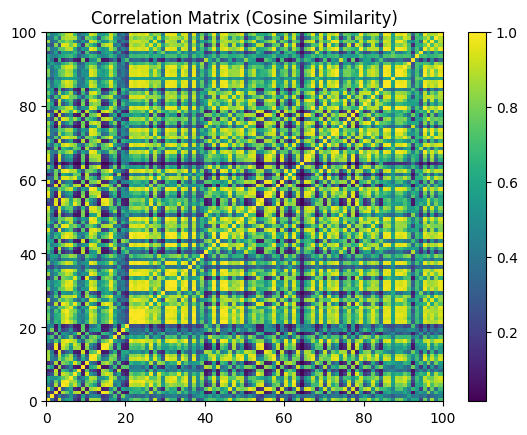

In [25]:
#  Compute a 100×100 correlation matrix C where you will compute the dot product (correlation)
# between the first 100 images in the matrix X. Thus each element is given by cjk = xT
# jxk where xj is
# the jth column of the matrix. Plot the correlation matrix using pcolor.

# Normalize each image to unit length so the dot product gives cosine similarity in [0, 1]
X_normed = X[:, :100] / np.linalg.norm(X[:, :100], axis=0, keepdims=True)

C=np.zeros((100,100))
for j in range(100):
    for k in range(100):
        # could have used np.dot as well
        C[j,k]=X_normed[:,j].T @ X_normed[:,k]
plt.pcolor(C)
plt.colorbar()
plt.title("Correlation Matrix (Cosine Similarity)")
plt.show()

# Why do we use the dot product to compute the correlation between two images? The dot product measures the similarity between two vectors (in this case, the pixel values of the images). 
# If the dot product is high, it indicates that the images are similar in terms of their pixel intensity patterns. T
# his is because the dot product sums the products of corresponding pixel values, which will be larger when the images have similar features and patterns.

Most correlated images: (np.int64(88), np.int64(95))
Most uncorrelated images: (np.int64(54), np.int64(64))


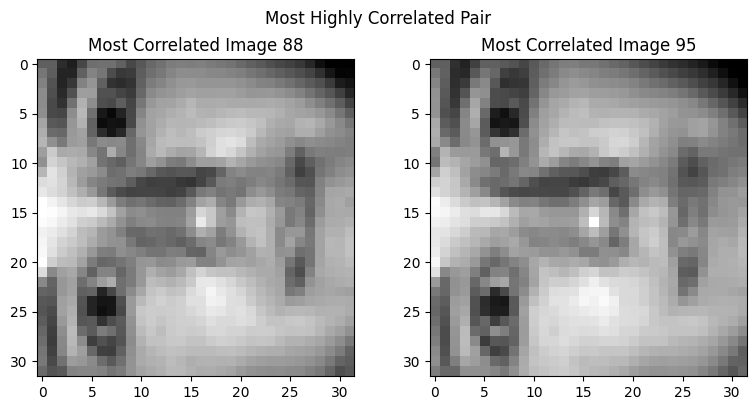

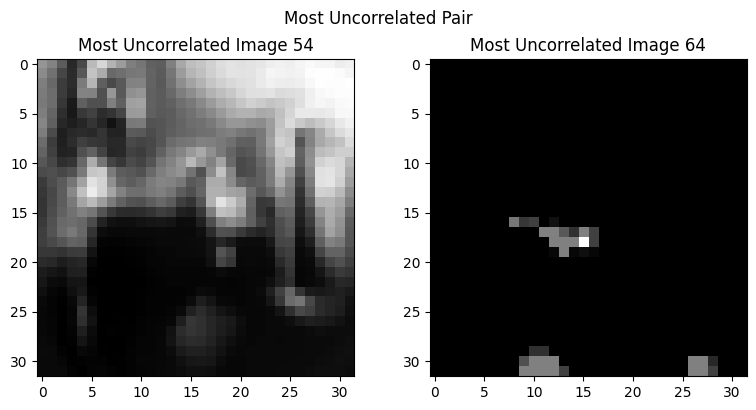

In [26]:
# From the correlation matrix for part (a), which two images are most highly correlated? Which
# are most uncorrelated? Plot these faces.

# We need to exclude the diagonal (self-correlation) since an image is always most correlated with itself
C_no_diag = C.copy()
np.fill_diagonal(C_no_diag, -np.inf)  # exclude diagonal for max search
most_correlated = np.unravel_index(np.argmax(C_no_diag, axis=None), C_no_diag.shape)
print("Most correlated images:", most_correlated)

# For most uncorrelated, the diagonal doesn't matter since self-correlation is the max, not the min
most_uncorrelated = np.unravel_index(np.argmin(C, axis=None), C.shape)
print("Most uncorrelated images:", most_uncorrelated)

# Plot the most correlated images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X[:, most_correlated[0]].reshape(32, 32).T, cmap='gray')
axes[0].set_title(f"Most Correlated Image {most_correlated[0]}")
axes[1].imshow(X[:, most_correlated[1]].reshape(32, 32).T, cmap='gray')
axes[1].set_title(f"Most Correlated Image {most_correlated[1]}")
plt.suptitle("Most Highly Correlated Pair")
plt.tight_layout()
plt.show()

# Plot the most uncorrelated images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X[:, most_uncorrelated[0]].reshape(32, 32).T, cmap='gray')
axes[0].set_title(f"Most Uncorrelated Image {most_uncorrelated[0]}")
axes[1].imshow(X[:, most_uncorrelated[1]].reshape(32, 32).T, cmap='gray')
axes[1].set_title(f"Most Uncorrelated Image {most_uncorrelated[1]}")
plt.suptitle("Most Uncorrelated Pair")
plt.tight_layout()
plt.show()

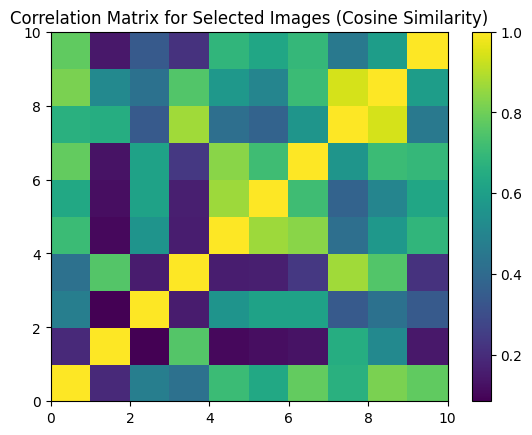

In [27]:
# Repeat part (a) but now compute the 10 ×10 correlation matrix between images and plot the
# correlation matrix between them.
# [1,313,512,5,2400,113,1024,87,314,2005].
# (Just for clarification, the first image is labeled as one, not zero like python might do)
indices = [1, 313, 512, 5, 2400, 113, 1024, 87, 314, 2005]

# Normalize the selected images to unit length (cosine similarity)
X_subset = X[:, [i - 1 for i in indices]]
X_subset_normed = X_subset / np.linalg.norm(X_subset, axis=0, keepdims=True)

C_subset = np.zeros((10, 10))
for j in range(10):
    for k in range(10):
        # same as before but now we are using the specified indices to compute the correlation matrix for the selected images
        C_subset[j, k] = X_subset_normed[:, j].T @ X_subset_normed[:, k]
plt.pcolor(C_subset)
plt.colorbar()
plt.title("Correlation Matrix for Selected Images (Cosine Similarity)")
plt.show()

In [28]:
# (d) Create the matrix Y = XX^T and find the first six eigenvectors with the largest magnitude eigenvalue.

# Normalize: subtract the mean face so PCA captures variance around the mean
mean_face = np.mean(X, axis=1, keepdims=True)
X_norm = X - mean_face

Y = X_norm @ X_norm.T

# Use eigh since Y is symmetric (more efficient and numerically stable)
eigenvalues, eigenvectors = np.linalg.eigh(Y)

# eigh returns eigenvalues in ascending order, so reverse to get largest first
sorted_indices = np.argsort(np.abs(eigenvalues))[::-1]
top_six_eigvecs = eigenvectors[:, sorted_indices[:6]]

print("Top 6 eigenvalues:", eigenvalues[sorted_indices[:6]])
print("\nShape of eigenvector matrix:", top_six_eigvecs.shape)

Top 6 eigenvalues: [51051.62812364 48975.14947832  6712.95943227  3878.84361432
  2035.44031626  1891.32009677]

Shape of eigenvector matrix: (1024, 6)


In [29]:
# (e) SVD the matrix X and find the first six principal component directions.
# We use the normalized X so that SVD performs PCA (captures variance around the mean)

U, S, Vt = np.linalg.svd(X_norm, full_matrices=False)

# The first 6 principal component directions are the first 6 columns of U
top_six_svd_modes = U[:, :6]

print("Singular values (first 6):", S[:6])
print("\nShape of U:", U.shape)

Singular values (first 6): [225.94607349 221.30329749  81.93265181  62.28036299  45.11585438
  43.48931014]

Shape of U: (1024, 1024)


In [30]:
# (f) Compare the first eigenvector v1 from (d) with the first SVD mode u1 from (e)
# and compute the norm of difference of their absolute values.

v1 = top_six_eigvecs[:, 0]  # from eigendecomposition of Y = XX^T
u1 = top_six_svd_modes[:, 0]  # from SVD of X

difference_norm = np.linalg.norm(np.abs(v1) - np.abs(u1))
print("Norm of the difference between |v1| and |u1|:", difference_norm)
# This should be very small (near zero), confirming that the eigenvectors of XX^T
# are the same as the left singular vectors of X.

Norm of the difference between |v1| and |u1|: 6.001005611000393e-15


Percentage of variance captured by the first 6 SVD modes:
  Mode 1: 38.1074%
  Mode 2: 36.5574%
  Mode 3: 5.0109%
  Mode 4: 2.8954%
  Mode 5: 1.5194%
  Mode 6: 1.4118%
  Total:  85.5021%


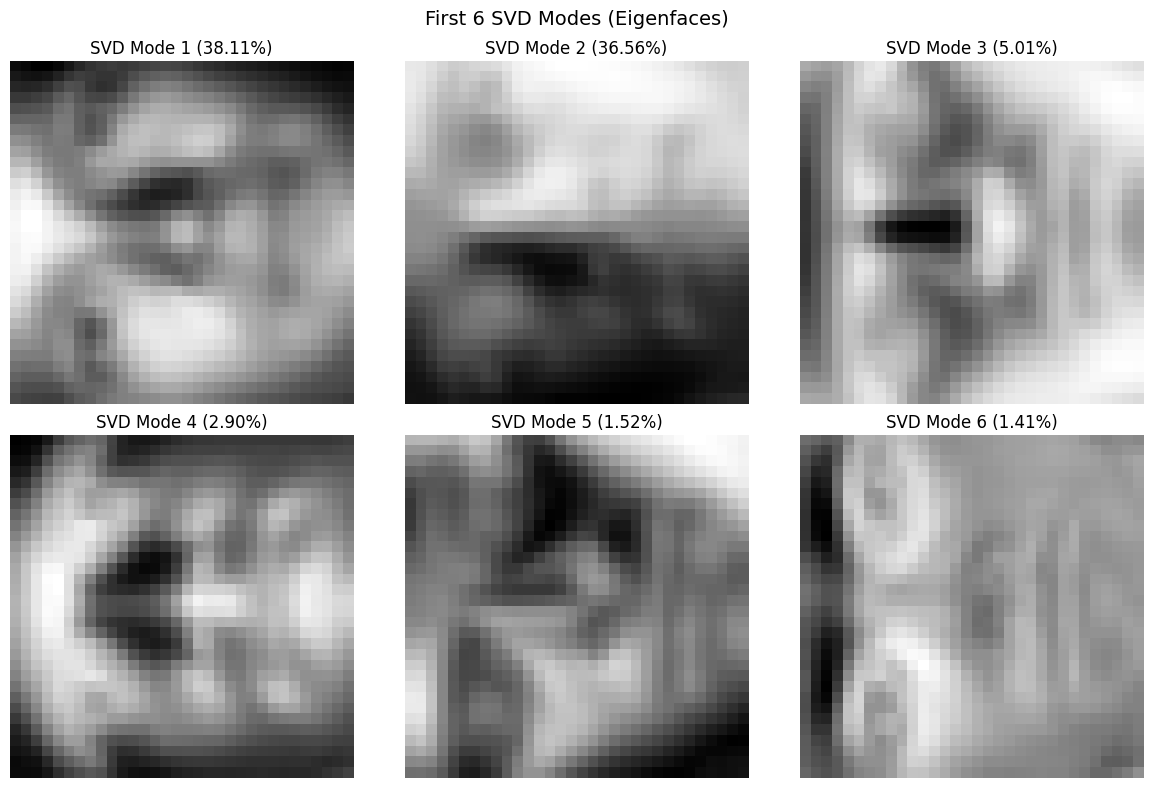

In [31]:
# (g) Compute the percentage of variance captured by each of the first 6 SVD modes.
# Plot the first 6 SVD modes.

variance_captured = (S[:6] ** 2) / np.sum(S ** 2) * 100
print("Percentage of variance captured by the first 6 SVD modes:")
for i, v in enumerate(variance_captured):
    print(f"  Mode {i+1}: {v:.4f}%")
print(f"  Total:  {np.sum(variance_captured):.4f}%")

# Plot the first 6 SVD modes as face images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(top_six_svd_modes[:, i].reshape(32, 32).T, cmap='gray')
    ax.set_title(f"SVD Mode {i+1} ({variance_captured[i]:.2f}%)")
    ax.axis('off')
plt.suptitle("First 6 SVD Modes (Eigenfaces)", fontsize=14)
plt.tight_layout()
plt.show()